**Question:**

You are given the root of a binary tree. Invert the binary tree in place. That is, all left children should become right children, and all right children should become left children.

**Example:**

- Input: a b d e c f
- Output: a c f b e d

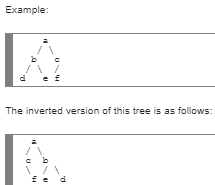

**Template:**

```python
class Node:
  def __init__(self, value):
    self.left = None
    self.right = None
    self.value = value
  def preorder(self):
    print self.value,
    if self.left: self.left.preorder()
    if self.right: self.right.preorder()

def invert(node):
  # Fill this in.

root = Node('a')
root.left = Node('b')
root.right = Node('c')
root.left.left = Node('d')
root.left.right = Node('e')
root.right.left = Node('f')

root.preorder()
# a b d e c f
print "\n"
invert(root)
root.preorder()
# a c f b e d

```


**Solution Methodology:**

A **recursive approach** is used for the tree inversion, as it allows the algorithm to traverse and swap nodes at every level, ensuring that all left children are swapped with their corresponding right children, and vice versa.

**Steps:**

1. **Base Case - Check if the Node is Null:**

   - If the current node is `None`, the function returns immediately. This handles the base case for recursion and prevents further processing of empty subtrees.

2. **Swap the Left and Right Children:**

   - For the current node, swap its left and right children. This ensures that the left child becomes the right child, and the right child becomes the left child.

3. **Recursive Inversion of the Subtrees:**

   - Recursively call the `invert` function on the left child (which was originally the right child) and the right child (which was originally the left child). This step continues the inversion process down the tree, ensuring that all subtrees are inverted as well.

4. **Complete the Inversion:**
   - The recursive calls ensure that the entire tree is inverted, from the root down to the leaf nodes. After the entire tree has been processed, all nodes will have their left and right children swapped, resulting in the desired inverted binary tree structure.


In [8]:
# solution
class Node:
  def __init__(self, value):
    self.left = None
    self.right = None
    self.value = value
  def preorder(self):
    print(self.value,  end=" ")
    if self.left: self.left.preorder()
    if self.right: self.right.preorder()

def invert(node):
  if node is None:
    return
  node.right, node.left = node.left, node.right
  invert(node.right)
  invert(node.left)


In [5]:
root = Node('a') 
root.left = Node('b') 
root.right = Node('c') 
root.left.left = Node('d') 
root.left.right = Node('e') 
root.right.left = Node('f') 

root.preorder()
# a b d e c f 
print("\n")
invert(root)
root.preorder()
# a c f b e d

a b d e c f 

a c f b e d 

In [9]:
# testing
def test_invert():
    # Helper function to generate a tree from a list of tuples
    def build_tree(nodes):
        if not nodes:
            return None
        val, left, right = nodes[0]
        root = Node(val)
        if left is not None:
            root.left = build_tree(left)
        if right is not None:
            root.right = build_tree(right)
        return root

    # Helper function to get the preorder traversal as a list
    def get_preorder(root):
        result = []
        if root:
            result.append(root.value)
            result.extend(get_preorder(root.left))
            result.extend(get_preorder(root.right))
        return result

    test_cases = [
        ([], []),  # Empty tree
        ([(1, None, None)], [1]),  # Single node tree
        ([(1, [(2, None, None)], [(3, None, None)])], [1, 3, 2]),  # Simple balanced tree
        ([(1, [(2, [(4, None, None)], [(5, None, None)])], [(3, None, None)])], [1, 3, 2, 5, 4]),  # Simple unbalanced tree
        ([(1, [(2, None, None)], None)], [1, 2]),  # Tree with only left children
        ([(1, None, [(2, None, None)])], [1, 2]),  # Tree with only right children
        ([(1, [(2, [(4, None, None)], None)], [(3, None, [(5, None, None)])])], [1, 3, 5, 2, 4]),  # Complex tree
        ([(1, [(2, [(3, [(4, None, None)], None)], None)], None)], [1, 2, 3, 4]),  # Skewed tree (left)
        ([(1, None, [(2, None, [(3, None, [(4, None, None)])])])], [1, 2, 3, 4]),  # Skewed tree (right)
    ]

    for i, (tree_data, expected_preorder) in enumerate(test_cases):
        root = build_tree(tree_data)
        invert(root)
        result_preorder = get_preorder(root)
        assert result_preorder == expected_preorder, f"Test case {i+1} failed: expected {expected_preorder}, got {result_preorder}"
        print(f"Test case {i+1} passed: expected {expected_preorder}, got {result_preorder}")

test_invert()


Test case 1 passed: expected [], got []
Test case 2 passed: expected [1], got [1]
Test case 3 passed: expected [1, 3, 2], got [1, 3, 2]
Test case 4 passed: expected [1, 3, 2, 5, 4], got [1, 3, 2, 5, 4]
Test case 5 passed: expected [1, 2], got [1, 2]
Test case 6 passed: expected [1, 2], got [1, 2]
Test case 7 passed: expected [1, 3, 5, 2, 4], got [1, 3, 5, 2, 4]
Test case 8 passed: expected [1, 2, 3, 4], got [1, 2, 3, 4]
Test case 9 passed: expected [1, 2, 3, 4], got [1, 2, 3, 4]
